По базе машин с ЮЛЫ данным обучите модель для предсказания цен на машины.

1. Создайте обучающую, тестовую и проверочную выборки.

2. Оцените качество работы созданной сети, определив средний процент ошибки на проверочной выборке. (Для этого потребуется привести предсказанные моделью значения к первоначальному диапазону цен.)  

3. Подсчитайте ошибку на каждом примере тестовой выборки и суммарный процент ошибки.


Рекомендации:
- в качестве ошибки рекомендуется использовать среднеквадратическую ошибку (mse).
- метрику для данной задачи можно не использовать.
- последний слой модели должен иметь 1 нейрон.
- суммарный процент ошибки = средний модуль ошибки (MAE) / среднюю цену машины. Например, если средняя цена машины 560.000 р, а средняя ошибка 56.000р, то процент ошибки равен 10%.


In [8]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import gdown

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout, BatchNormalization

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler


In [9]:
DATA_URL = 'https://storage.yandexcloud.net/aiueducation/Content/base/l10/cars_new.csv'
DATA_FILE = 'cars_new.csv'

# Загрузка таблицы с автомобилями
def load_cars_table(url=DATA_URL, file_name=DATA_FILE):
    gdown.download(url, file_name, quiet=True)
    table = pd.read_csv(file_name)
    table = table.dropna().copy()
    return table


# Перевод цены из текстового формата в число
def price_to_number(value):
    digits = ''.join(ch for ch in str(value) if ch.isdigit())
    return int(digits)


# Загрузка базы и преобразование столбца цены
cars_df = load_cars_table()
cars_df['price'] = cars_df['price'].apply(price_to_number)

# Средняя цена
avg_price = cars_df['price'].mean()
print(f'Средняя цена автомобиля в базе: {round(avg_price, 2)} руб.')


Средняя цена автомобиля в базе: 527724.09 руб.


In [10]:
# Категориальные, числовые и целевой столбцы
CAT_COLUMNS = ['mark', 'model', 'fuel', 'body']
NUM_COLUMNS = ['year', 'mileage']
TARGET_COLUMN = 'price'


# Формирование входных признаков и целевого значения
def make_feature_matrix(table):
    # Преобразование категориальных признаков в числовые через one-hot кодирование
    cat_part = pd.get_dummies(table[CAT_COLUMNS])

    # Объединение закодированных категорий и числовых признаков
    raw_features = np.hstack([cat_part.values, table[NUM_COLUMNS].values])

    # Масштабирование входных признаков
    feature_scaler = StandardScaler()
    features = feature_scaler.fit_transform(raw_features)

    # Масштабирование цены, чтобы нейросети было проще обучаться
    target_scaler = StandardScaler()
    target = target_scaler.fit_transform(table[[TARGET_COLUMN]].values)

    return features, target, feature_scaler, target_scaler


# Подготовка признаков и целевой переменной
x_all, y_all, x_scaler, y_scaler = make_feature_matrix(cars_df)


In [11]:
# Разделение данных на обучающую, проверочную и тестовую выборки
def make_train_val_test_split(features, target):
    # 80% данных используется для обучения, остальные 20% временно откладываются
    x_train, x_temp, y_train, y_temp = train_test_split(
        features,
        target,
        train_size=0.8
    )

    # Оставшиеся 20% делятся поровну на проверочную и тестовую выборки
    x_val, x_test, y_val, y_test = train_test_split(
        x_temp,
        y_temp,
        test_size=0.5
    )

    return x_train, x_val, x_test, y_train, y_val, y_test


# Получение трех наборов данных
x_train, x_val, x_test, y_train, y_val, y_test = make_train_val_test_split(x_all, y_all)

print('Размер обучающей выборки:', x_train.shape)
print('Размер проверочной выборки:', x_val.shape)
print('Размер тестовой выборки:', x_test.shape)


Размер обучающей выборки: (56089, 3200)
Размер проверочной выборки: (7011, 3200)
Размер тестовой выборки: (7012, 3200)


In [5]:
# Создание нейросетевой модели для регрессии
def build_price_model(input_size):
    network = Sequential()

    # Первый полносвязный слой принимает все подготовленные признаки автомобиля
    network.add(Dense(256, activation='relu', input_shape=(input_size,)))

    # Нормализация стабилизирует обучение
    network.add(BatchNormalization())

    # Скрытые слои выделяют зависимости между признаками и ценой
    network.add(Dense(128, activation='relu'))
    network.add(Dropout(0.2))
    network.add(Dense(64, activation='relu'))

    # Последний слой выдает одно число: предсказанную цену в масштабированном виде
    network.add(Dense(1, activation='linear'))

    # Для задачи регрессии используется среднеквадратичная ошибка
    network.compile(
        optimizer='adam',
        loss='mse'
    )

    return network


# Создание и обучение модели
model = build_price_model(x_train.shape[1])

history = model.fit(
    x_train,
    y_train,
    epochs=50,
    batch_size=32,
    validation_data=(x_val, y_val),
    verbose=1
)


/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Epoch 1/50
1753/1753 ━━━━━━━━━━━━━━━━━━━━ 11s 5ms/step - loss: 0.4680 - val_loss: 0.2293
Epoch 2/50
1753/1753 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - loss: 0.2537 - val_loss: 0.2113
Epoch 3/50
1753/1753 ━━━━━━━━━━━━━━━━━━━━ 6s 3ms/step - loss: 0.1932 - val_loss: 0.2086
Epoch 4/50
1753/1753 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - loss: 0.1684 - val_loss: 0.2374
Epoch 5/50
1753/1753 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - loss: 0.1343 - val_loss: 0.3819
Epoch 6/50
1753/1753 ━━━━━━━━━━━━━━━━━━━━ 6s 3ms/step - loss: 0.1744 - val_loss: 0.2832
Epoch 7/50
1753/1753 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - loss: 0.1325 - val_loss: 0.6146
Epoch 8/50
1753/1753 ━━━━━━━━━━━━━━━━━━━━ 6s 4ms/step - loss: 0.1307 - val_loss: 0.1332
Epoch 9/50
1753/1753 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - loss: 0.1169 - val_loss: 0.1874
Epoch 10/50
1753/1753 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - loss: 0.1426 - val_loss: 0.2646
Epoch 11/50
1753/1753 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - loss: 0.1211 - val_loss: 0.3642
Epoch 12/50
1753/1753 ━━━━━━━

In [6]:
# Возврат масштабированных значений цены к исходному диапазону
def restore_prices(values, scaler):
    return scaler.inverse_transform(values).reshape(-1)


# Проверка модели на тестовой выборке
def estimate_model(model, x_test, y_test, scaler, base_price):
    # Получение предсказаний модели
    predicted_scaled = model.predict(x_test)

    # Возврат предсказанных и реальных цен в рубли
    predicted_prices = restore_prices(predicted_scaled, scaler)
    real_prices = restore_prices(y_test, scaler)

    # Расчет ошибки по каждому примеру
    abs_errors = np.abs(predicted_prices - real_prices)

    # Средняя абсолютная ошибка в рублях
    mae_value = abs_errors.mean()

    # Итоговый процент ошибки относительно средней цены автомобиля
    total_error_percent = mae_value / base_price * 100

    return predicted_prices, real_prices, abs_errors, mae_value, total_error_percent


# Расчет качества модели
pred_prices, true_prices, example_errors, mae, total_error = estimate_model(
    model,
    x_test,
    y_test,
    y_scaler,
    avg_price
)

print(f'Средняя ошибка (MAE): {round(mae, 2)} руб.')
print(f'Суммарный процент ошибки: {round(total_error, 2)}%')


220/220 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step
Средняя ошибка (MAE): 230260.44 руб.
Суммарный процент ошибки: 43.63%


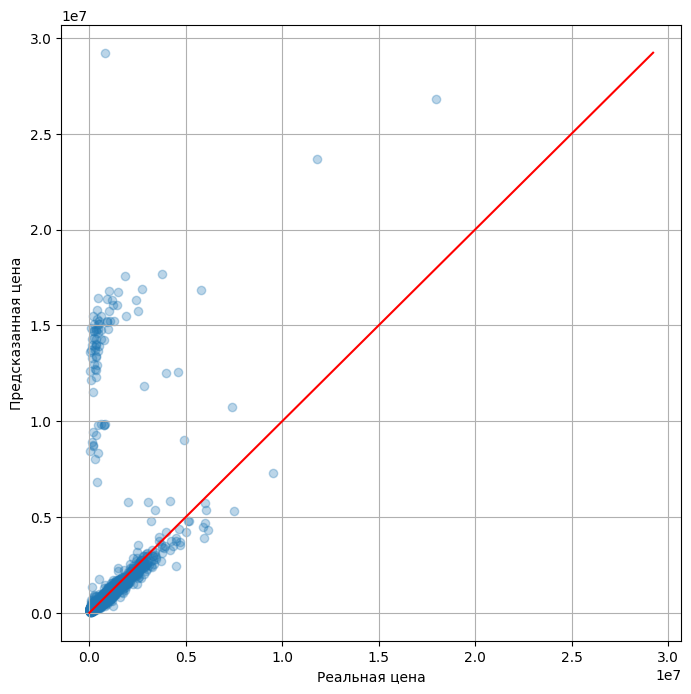

In [7]:
# Построение графика сравнения реальных и предсказанных цен
def show_prediction_scatter(real_values, predicted_values):
    upper_limit = max(real_values.max(), predicted_values.max())

    plt.figure(figsize=(8, 8))

    # Каждая точка показывает одну машину из тестовой выборки
    plt.scatter(real_values, predicted_values, alpha=0.3)

    # Красная линия показывает идеальное совпадение прогноза и реальной цены
    plt.plot([0, upper_limit], [0, upper_limit], 'r')

    plt.xlabel('Реальная цена')
    plt.ylabel('Предсказанная цена')
    plt.grid(True)
    plt.show()


show_prediction_scatter(true_prices, pred_prices)
